In [32]:
from keras.datasets import mnist

In [33]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

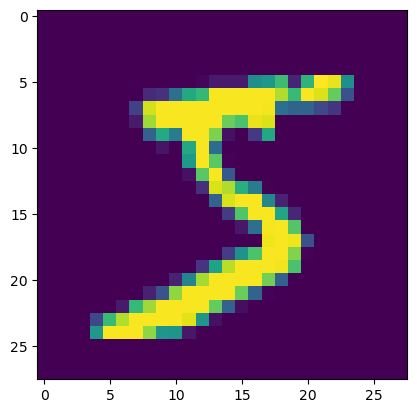

In [34]:
from matplotlib import pyplot as plt

plt.imshow(x_train[0])

In [35]:
x_train = x_train/255.0
x_test = x_test/255.0

In [36]:
from keras import layers, activations, models, optimizers, losses, metrics

In [6]:
data_augmentation = models.Sequential([
    layers.Input(shape=(28,28, 1)),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.05),
])

I0000 00:00:1789467569.947360  534778 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9446 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


In [ ]:
classifier = models.Sequential(
    [
        data_augmentation,
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3),activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3),activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ]
)

classifier.build()

classifier.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,13

 Total params: 409,962 (1.56 MB)

 Trainable params: 408,298 (1.56 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
from keras import callbacks

file_path = 'models_experiment_6/weights.{epoch:02d}-{val_sparse_categorical_accuracy:.4f}.keras'

lr_reduction = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=1-0.2,
    patience=5,
    verbose=1,
)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath=file_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

In [9]:

classifier.compile(
    optimizer=optimizers.Adam(),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy()],
)

In [10]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [11]:
x_train[0].shape

(28, 28)

In [12]:
classifier.fit(
    x=x_train,
    y=y_train,
    epochs=100,
    validation_data=(x_test, y_test),
    callbacks=[lr_reduction, model_checkpoint]
)

Epoch 1/100


2026-09-15 16:19:30.884562: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.
2026-09-15 16:19:31.047931: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.
E0000 00:00:1789467573.067689  534778 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-09-15 16:19:33.513307: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7435 - sparse_categorical_accuracy: 0.7756
Epoch 1: val_loss improved from None to 0.03063, saving model to models_experiment_6/weights.01-0.9901.keras

Epoch 1: finished saving model to models_experiment_6/weights.01-0.9901.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 0.3737 - sparse_categorical_accuracy: 0.8871 - val_loss: 0.0306 - val_sparse_categorical_accuracy: 0.9901 - learning_rate: 0.0010
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1423 - sparse_categorical_accuracy: 0.9575
Epoch 2: val_loss improved from 0.03063 to 0.02835, saving model to models_experiment_6/weights.02-0.9916.keras

Epoch 2: finished saving model to models_experiment_6/weights.02-0.9916.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.1278 - sparse_categorical_accuracy: 0.9619 - val_loss: 0.0284 - val_sparse_categorical_accuracy: 0.9916 - learning_rate: 0.0010
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 10m

In [23]:
import pandas as pd

pd.DataFrame(
    classifier.history.history
).plot()

AttributeError: 'Sequential' object has no attribute 'history'

In [24]:
classifier = models.load_model('models_experiment_6/weights.94-0.9966.keras')

In [25]:
predictions = classifier.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [26]:
import numpy as np

predictions = np.argmax(predictions, axis=1)

In [27]:
predictions

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=predictions, digits=4))

              precision    recall  f1-score   support

           0     0.9969    1.0000    0.9985       980
           1     0.9965    0.9991    0.9978      1135
           2     0.9981    0.9981    0.9981      1032
           3     0.9931    0.9990    0.9961      1010
           4     0.9919    0.9969    0.9944       982
           5     0.9989    0.9944    0.9966       892
           6     0.9990    0.9937    0.9963       958
           7     0.9971    0.9951    0.9961      1028
           8     0.9979    0.9969    0.9974       974
           9     0.9970    0.9921    0.9945      1009

    accuracy                         0.9966     10000
   macro avg     0.9966    0.9965    0.9966     10000
weighted avg     0.9966    0.9966    0.9966     10000



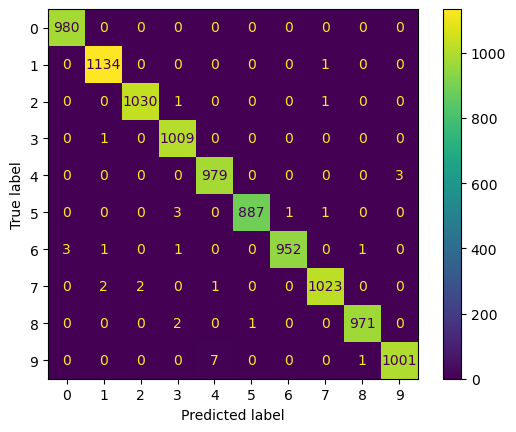

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_pred=predictions, y_true=y_test)

In [20]:
index_array = []

for i in range(len(y_test)):
    if y_test[i] == 7:
        index_array.append(i)



index_array

[0,
 17,
 26,
 34,
 36,
 41,
 60,
 64,
 70,
 75,
 79,
 80,
 83,
 86,
 97,
 111,
 114,
 122,
 124,
 133,
 141,
 144,
 171,
 175,
 220,
 223,
 229,
 234,
 243,
 254,
 255,
 262,
 263,
 282,
 301,
 307,
 328,
 337,
 358,
 370,
 383,
 410,
 411,
 413,
 415,
 438,
 468,
 482,
 494,
 510,
 522,
 550,
 551,
 554,
 557,
 579,
 585,
 605,
 617,
 626,
 636,
 649,
 651,
 658,
 666,
 667,
 676,
 679,
 684,
 689,
 702,
 703,
 705,
 726,
 730,
 746,
 756,
 771,
 810,
 822,
 825,
 832,
 841,
 842,
 846,
 852,
 853,
 859,
 880,
 898,
 909,
 911,
 917,
 930,
 941,
 946,
 950,
 960,
 987,
 1006,
 1012,
 1021,
 1039,
 1055,
 1071,
 1091,
 1096,
 1100,
 1104,
 1110,
 1117,
 1119,
 1122,
 1126,
 1133,
 1141,
 1143,
 1156,
 1164,
 1171,
 1173,
 1175,
 1186,
 1194,
 1206,
 1216,
 1226,
 1241,
 1244,
 1260,
 1276,
 1283,
 1321,
 1326,
 1328,
 1346,
 1347,
 1355,
 1359,
 1361,
 1363,
 1366,
 1369,
 1386,
 1401,
 1477,
 1494,
 1496,
 1497,
 1498,
 1500,
 1505,
 1507,
 1520,
 1522,
 1540,
 1543,
 1544,
 1563,
 1

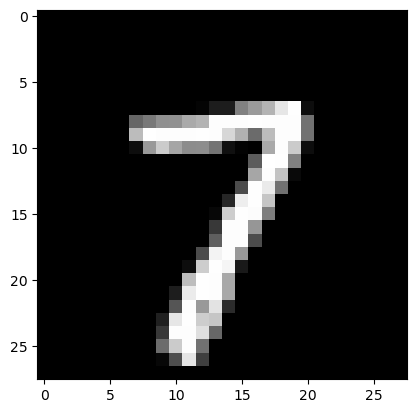

In [21]:
import random

i = random.choice(index_array)

image = x_test[i]

plt.imshow(image, cmap='gray')

In [22]:
classifier.save('best_model.keras')